In [1]:
import setup_paths
import config
import hashlib
import torch
import numpy as np
import matplotlib.pyplot as plt
from dataloader import set_global_seeds, get_dataloader, compute_class_weights

from config import SPLIT_LAB_CSV, PREPROCESSED_DIR

set_global_seeds(42)

In [2]:
# Test Dataloader
print("--- TESTING DATALOADER ---")
try:
    train_loader = get_dataloader(
        split="train_sessions",
        csv_path=SPLIT_LAB_CSV,
        data_dir=PREPROCESSED_DIR,
        batch_size=4,
        augment=True,
        num_workers=0  # Set to 0 for notebook testing to avoid multiprocessing bugs
    )

    # Grab one batch
    batch_x, batch_y, batch_sessions = next(iter(train_loader))

    print(f"Batch loaded successfully!")
    print(f"X shape (Expected [4, 3, 128, 128, 128]): {batch_x.shape}")
    print(f"Y shape (Expected [4]): {batch_y.shape}")
    print(f"X dtype (Expected torch.float32): {batch_x.dtype}")
    print(f"Y dtype (Expected torch.int64): {batch_y.dtype}")
    print(f"Session IDs: {batch_sessions}")

    # Sanity check values
    # Should be near 0.0
    print(f"Min value in batch: {batch_x.min().item():.4f}")
    # Should be near 1.0 or slightly >1.0 due to noise/scaling
    print(f"Max value in batch: {batch_x.max().item():.4f}")

except Exception as e:
    print(f"Dataloader crashed: {e}")

--- TESTING DATALOADER ---
Batch loaded successfully!
X shape (Expected [4, 3, 128, 128, 128]): torch.Size([4, 3, 128, 128, 128])
Y shape (Expected [4]): torch.Size([4])
X dtype (Expected torch.float32): torch.float32
Y dtype (Expected torch.int64): torch.int64
Session IDs: ('389_S_10378_sc', '052_S_10202_sc', '082_S_10220_sc', '114_S_6813_init')
Min value in batch: 0.0000
Max value in batch: 1.0693


In [3]:
# Test Class Weights
print("\n--- TESTING CLASS WEIGHTS ---")
weights = compute_class_weights(SPLIT_LAB_CSV, "train_sessions")
print(f"Computed Class Weights (CN, MCI, AD): {weights}")


--- TESTING CLASS WEIGHTS ---
Computed Class Weights (CN, MCI, AD): tensor([0.6453, 0.8137, 4.5170])


Class 0 (CN - Cognitively Normal) = 0.64

Class 1 (MCI - Mild Cognitive Impairment) = 0.81

Class 2 (AD - Alzheimer's Disease) = 4.51

This is because the training set (but also the whole dataset) is imbalanced. A weight of 4.51 means Alzheimer's patients are extremely rare in training set compared to healthy patients. When building the training loop, passing these exact weights into your CrossEntropyLoss will force the model to pay 4.5x more attention whenever it sees an actual Alzheimer's patient, preventing it from just guessing "Healthy" every time to cheat the accuracy metric.

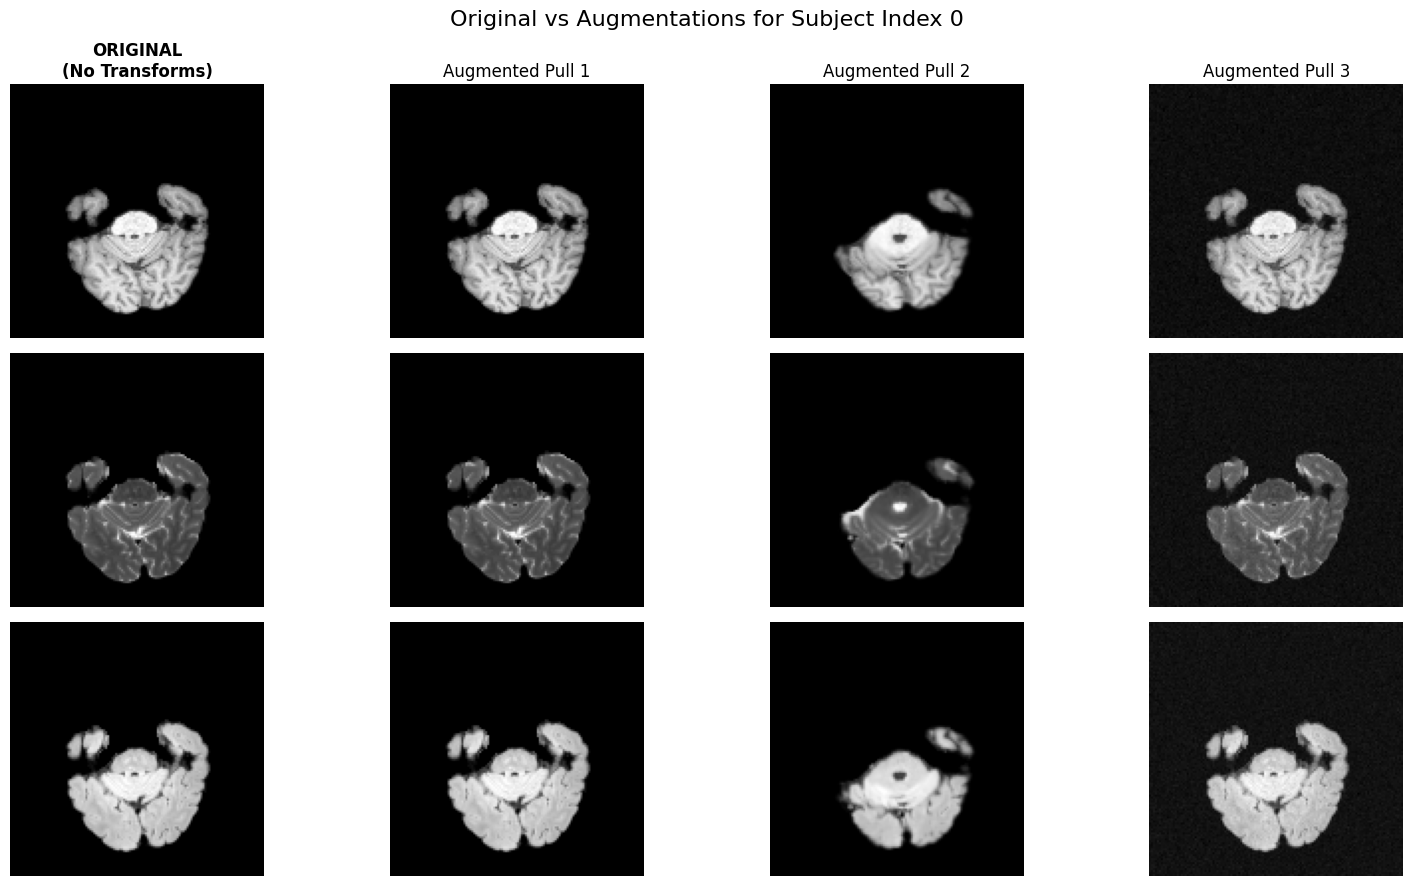

In [4]:
# Visualize Augmentations
def plot_augmentations(dataset, subject_idx=0, num_variations=3):
    """
    Plots the original un-augmented image in the first column,
    followed by 'num_variations' augmented versions.
    """
    # Total columns = 1 (Original) + num_variations (Augmented)
    total_cols = num_variations + 1
    fig, axes = plt.subplots(3, total_cols, figsize=(total_cols * 4, 9))
    fig.suptitle(f"Original vs Augmentations for Subject Index {subject_idx}", fontsize=16)

    # --- 1. Get the ORIGINAL (Un-augmented) ---
    # Temporarily detach the transform to get the raw image
    original_transform = dataset.transform
    dataset.transform = None
    x_orig, _, _ = dataset[subject_idx]
    
    # Put the transform back so we can get augmentations!
    dataset.transform = original_transform 

    # We will plot the middle axial slice
    slice_idx = x_orig.shape[2] // 2 

    # Plot original in column 0
    for c in range(3):
        ax = axes[c, 0]
        img_slice = x_orig[c, :, :, slice_idx].numpy()
        ax.imshow(img_slice.T, cmap="gray", origin="lower")
        ax.axis("off")
        if c == 0:
            ax.set_title("ORIGINAL\n(No Transforms)", fontweight="bold")

    # --- 2. Get the AUGMENTED variations ---
    for i in range(1, total_cols):
        # Because the transform is back, this will trigger the random augmentations
        x_aug, _, _ = dataset[subject_idx]
        
        for c in range(3):
            ax = axes[c, i]
            img_slice = x_aug[c, :, :, slice_idx].numpy()
            ax.imshow(img_slice.T, cmap="gray", origin="lower")
            ax.axis("off")
            if c == 0:
                ax.set_title(f"Augmented Pull {i}")

    plt.tight_layout()
    plt.show()

# Run it (1 original + 3 augmented versions = 4 columns)
plot_augmentations(train_loader.dataset, subject_idx=0, num_variations=3)

The first column shows the original images, the other three show the same subject but processed through random augmentations.

The visualization proves that the augmentation is working perfectly. In fact, it is possible to see the exact same brain, but slightly shifted, rotated, and varying in brightness.

This makes sure that the CNN won't just memorize one static picture of a patient. Instead it will have to learn the actual biological shape of the brain from multiple angles and lighting conditions.